# Лабораторная работа
## Тема: Машины опорных векторов (SVM)

### 1. Название и краткая информация о сдаваемом методе

Метод опорных векторов (Support Vector Machine, SVM) применяется для задач классификации и регрессии. Его идея состоит в поиске такой разделяющей гиперплоскости, которая максимально увеличивает зазор между классами. В данной лабораторной работе рассматривается SVM-классификатор с `RBF`-ядром для бинарной классификации качества вина на основе физико-химических характеристик и типа напитка.
        


### 2. Блок с используемыми библиотеками

В работе используются библиотеки `pandas` и `numpy` для загрузки и обработки данных, `matplotlib` и `seaborn` для визуализации, а также инструменты `scikit-learn` для предобработки признаков, обучения SVM-модели и оценки качества классификации.
        


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid", font_scale=1.0)
RANDOM_STATE = 42
        


### 3. Блок с описанием и демонстрацией используемого датасета

Для лабораторной работы используется датасет **Wine Quality**, объединяющий сведения о красном и белом вине. В набор входят физико-химические характеристики образцов: кислотность, содержание сахара, плотность, уровень pH, концентрация сернистых соединений, содержание алкоголя и тип вина. Целевая переменная `quality_label` является бинарной и показывает, относится ли образец к более качественным винам.
        


In [2]:
candidate_paths = [
    Path("svm_wine_quality.csv"),
    Path("/content/svm_wine_quality.csv"),
    Path("/mnt/data/svm_wine_quality.csv"),
]

for path in candidate_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("Файл svm_wine_quality.csv не найден рядом с ноутбуком.")

df = pd.read_csv(data_path)

print(f"Используемый файл: {data_path}")
print(f"Размер датасета: {df.shape[0]} строк и {df.shape[1]} столбцов")
display(df.head(10))
        


Используемый файл: svm_wine_quality.csv
Размер датасета: 6497 строк и 14 столбцов


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,1
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,1
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white,1
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white,1
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,white,1
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white,1
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white,1
9,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,white,1


In [3]:
print("Информация о датасете:")
df.info()

print("\nСтатистическое описание числовых признаков:")
display(df.describe().round(3))

print("\nКоличество пропусков по столбцам:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nРаспределение целевой переменной quality_label:")
class_distribution = (
    df["quality_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "обычное/низкое качество", 1: "хорошее качество"})
    .to_frame("count")
)
display(class_distribution)
        


Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   str    
 13  quality_label         6497 non-null   int64  
dtypes: float64(11), int64(2), str(1)
memory usage: 710.7 KB

Ста

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818,0.633
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873,0.482
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000,0.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000,0.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000,1.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000,1.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000,1.000



Количество пропусков по столбцам:


,missing_values
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Распределение целевой переменной quality_label:


,count
quality_label,
обычное/низкое качество,2384
хорошее качество,4113


### 4. Блок с предварительной обработкой датасета

На этапе предобработки отделяются признаки от целевой переменной, после чего признаки делятся на числовые и категориальные. Для числовых столбцов выполняются заполнение возможных пропусков медианой и стандартизация, так как SVM чувствителен к масштабу признаков. Для категориального признака `wine_type` применяется заполнение наиболее частым значением и one-hot кодирование. Далее датасет разбивается на обучающую и тестовую выборки с сохранением пропорции классов.
        


In [20]:
X = df.drop(columns=["quality_label", "quality"])
y = df["quality_label"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("Числовые признаки:")
print(numeric_features)
print("\nКатегориальные признаки:")
print(categorical_features)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
        


Числовые признаки:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Категориальные признаки:
['wine_type']
Размер обучающей выборки: (5522, 12)
Размер тестовой выборки: (975, 12)


### 5. Блок с тепловой картой

Тепловая карта позволяет увидеть силу линейной связи между числовыми признаками и целевой переменной `quality_label`. Так как признак `wine_type` является категориальным, он не включается в корреляционную матрицу. Для более наглядного отображения выбираются признаки, сильнее всего связанные с целевой переменной по модулю коэффициента корреляции.
        


Наиболее связанные с quality_label признаки:


,corr_with_quality_label
quality,0.814
alcohol,0.395
density,-0.269
volatile acidity,-0.267
chlorides,-0.182
citric acid,0.076
fixed acidity,-0.067
total sulfur dioxide,-0.048


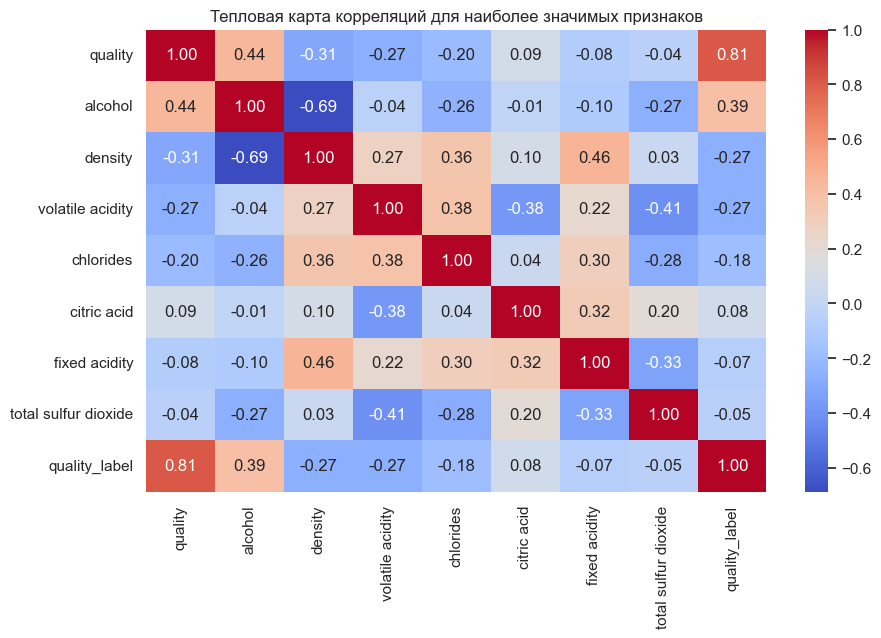

In [21]:
corr_df = df.drop(columns=["wine_type"]).copy()
target_corr = (
    corr_df.corr(numeric_only=True)["quality_label"]
    .drop("quality_label")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
top_features = target_corr.head(8).index.tolist()

print("Наиболее связанные с quality_label признаки:")
display(target_corr.head(8).round(3).to_frame("corr_with_quality_label"))

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_df[top_features + ["quality_label"]].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
)
plt.title("Тепловая карта корреляций для наиболее значимых признаков")
plt.show()
        


### 6. Блок с обучением модели

Для обучения используется классификатор `SVC` с `RBF`-ядром. Такое ядро позволяет учитывать нелинейные границы между классами. Параметр `C=5.0` задаёт степень штрафа за ошибки классификации, а `gamma="scale"` автоматически подстраивает масштаб ядра под распределение данных. Модель обучается внутри единого конвейера вместе с шагом предобработки признаков.
        


In [22]:
svm_clf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", SVC(kernel="rbf", C=5.0, gamma="scale")),
    ]
)

svm_clf.fit(X_train, y_train)

print("Модель успешно обучена.")


Модель успешно обучена.


### 7. Блок с прогнозами модели

После обучения модель применяется к тестовой выборке. В этом блоке выводятся примеры предсказаний, таблица основных метрик и подробный классификационный отчёт, позволяющий оценить точность, полноту и F1-меру для каждого класса.
        


In [23]:
y_pred = svm_clf.predict(X_test)

comparison = X_test.reset_index(drop=True).copy()
comparison["Истинный класс"] = y_test.reset_index(drop=True).map(
    {0: "обычное/низкое качество", 1: "хорошее качество"}
)
comparison["Предсказанный класс"] = pd.Series(y_pred).map(
    {0: "обычное/низкое качество", 1: "хорошее качество"}
)

display(comparison.head(15))

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame(
    {
        "Метрика": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Значение": [accuracy, precision, recall, f1],
    }
)

display(metrics_df.round({"Значение": 4}))

print("Классификационный отчёт:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["обычное/низкое качество", "хорошее качество"],
    )
)
        


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,wine_type,Истинный класс,Предсказанный класс
0,5.4,0.150,0.32,2.5,0.037,10.0,51.0,0.98878,3.04,0.58,12.6,white,хорошее качество,хорошее качество
1,6.9,0.190,0.28,5.0,0.058,14.0,146.0,0.99520,3.29,0.36,9.1,white,хорошее качество,обычное/низкое качество
2,7.2,0.230,0.39,2.3,0.033,29.0,102.0,0.99080,3.26,0.54,12.3,white,хорошее качество,хорошее качество
3,8.9,0.270,0.34,10.7,0.029,19.5,166.0,0.99669,3.13,0.48,10.6,white,обычное/низкое качество,хорошее качество
4,5.8,0.250,0.24,13.3,0.044,41.0,137.0,0.99720,3.34,0.42,9.5,white,обычное/низкое качество,хорошее качество
5,6.5,0.300,0.27,4.0,0.038,37.0,97.0,0.99026,3.20,0.60,12.6,white,хорошее качество,хорошее качество
6,6.0,0.280,0.52,6.2,0.028,37.0,104.0,0.99161,3.28,0.51,11.8,white,хорошее качество,хорошее качество
7,7.0,0.160,0.73,1.0,0.138,58.0,150.0,0.99360,3.08,0.30,9.2,white,обычное/низкое качество,хорошее качество
8,7.4,0.105,0.34,12.2,0.050,57.0,146.0,0.99730,3.16,0.37,9.0,white,хорошее качество,хорошее качество
9,8.4,0.190,0.43,2.1,0.052,20.0,104.0,0.99400,2.85,0.46,9.5,white,обычное/низкое качество,обычное/низкое качество


,Метрика,Значение
0,Accuracy,0.7877
1,Precision,0.8144
2,Recall,0.8606
3,F1-score,0.8369


Классификационный отчёт:
                         precision    recall  f1-score   support

обычное/низкое качество       0.73      0.66      0.70       358
       хорошее качество       0.81      0.86      0.84       617

               accuracy                           0.79       975
              macro avg       0.77      0.76      0.77       975
           weighted avg       0.78      0.79      0.79       975



### 8. Блок с графиками выходных результатов

В итоговом блоке строятся основные графики, иллюстрирующие работу модели: матрица ошибок, столбчатая диаграмма по основным метрикам и валидационная кривая по параметру `C`. Эти визуализации помогают оценить качество классификации и устойчивость модели при разных настройках регуляризации.
        


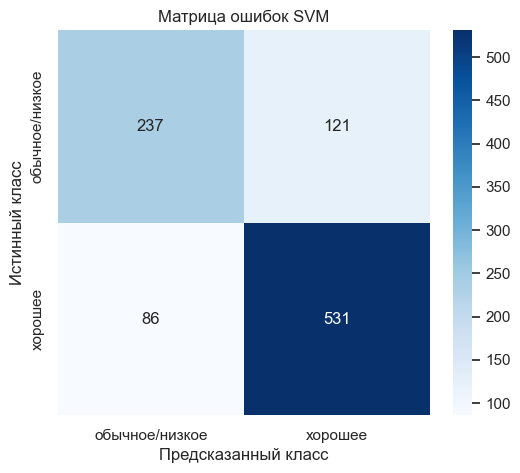

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["обычное/низкое", "хорошее"],
    yticklabels=["обычное/низкое", "хорошее"],
)
plt.title("Матрица ошибок SVM")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()
        


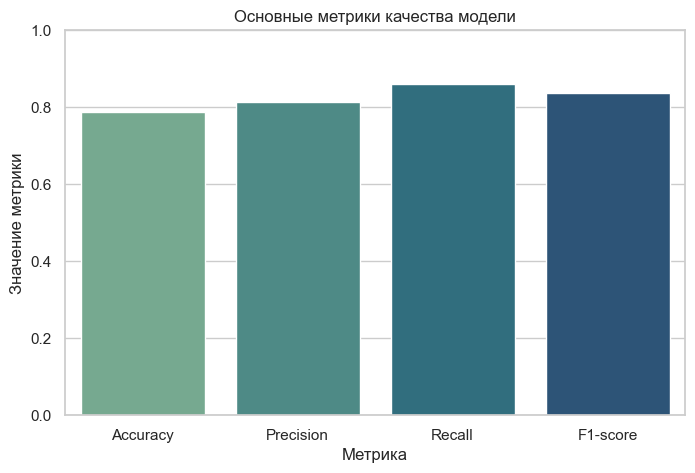

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x="Метрика", y="Значение", palette="crest")
plt.ylim(0, 1)
plt.title("Основные метрики качества модели")
plt.ylabel("Значение метрики")
plt.show()
        


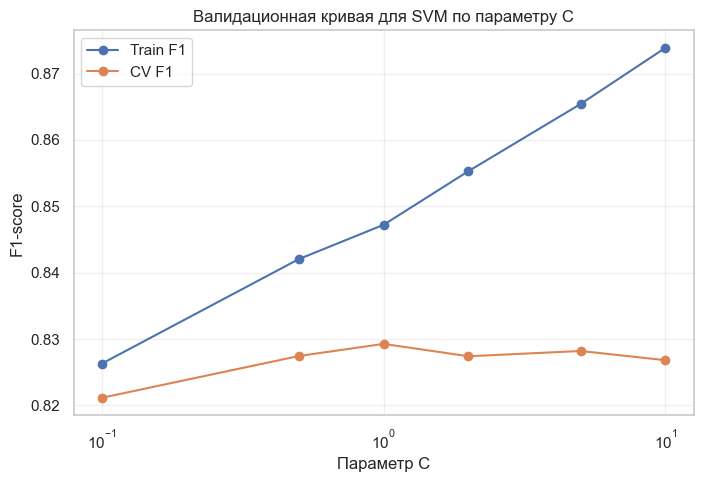

In [19]:
param_range = [0.1, 0.5, 1, 2, 5, 10]

train_scores, test_scores = validation_curve(
    svm_clf,
    X_train,
    y_train,
    param_name="model__C",
    param_range=param_range,
    cv=5,
    scoring="f1",
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(param_range, train_mean, marker="o", label="Train F1")
plt.plot(param_range, test_mean, marker="o", label="CV F1")
plt.xscale("log")
plt.xlabel("Параметр C")
plt.ylabel("F1-score")
plt.title("Валидационная кривая для SVM по параметру C")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
        


**Итог:** SVM-модель с `RBF`-ядром показывает устойчивое качество на датасете Wine Quality и корректно отделяет более качественные вина от обычных по совокупности физико-химических признаков и типа вина.
        
